|--------------------------------Sales Exploratory Data Analysis + Extract, Transform & Load-------------------------------|

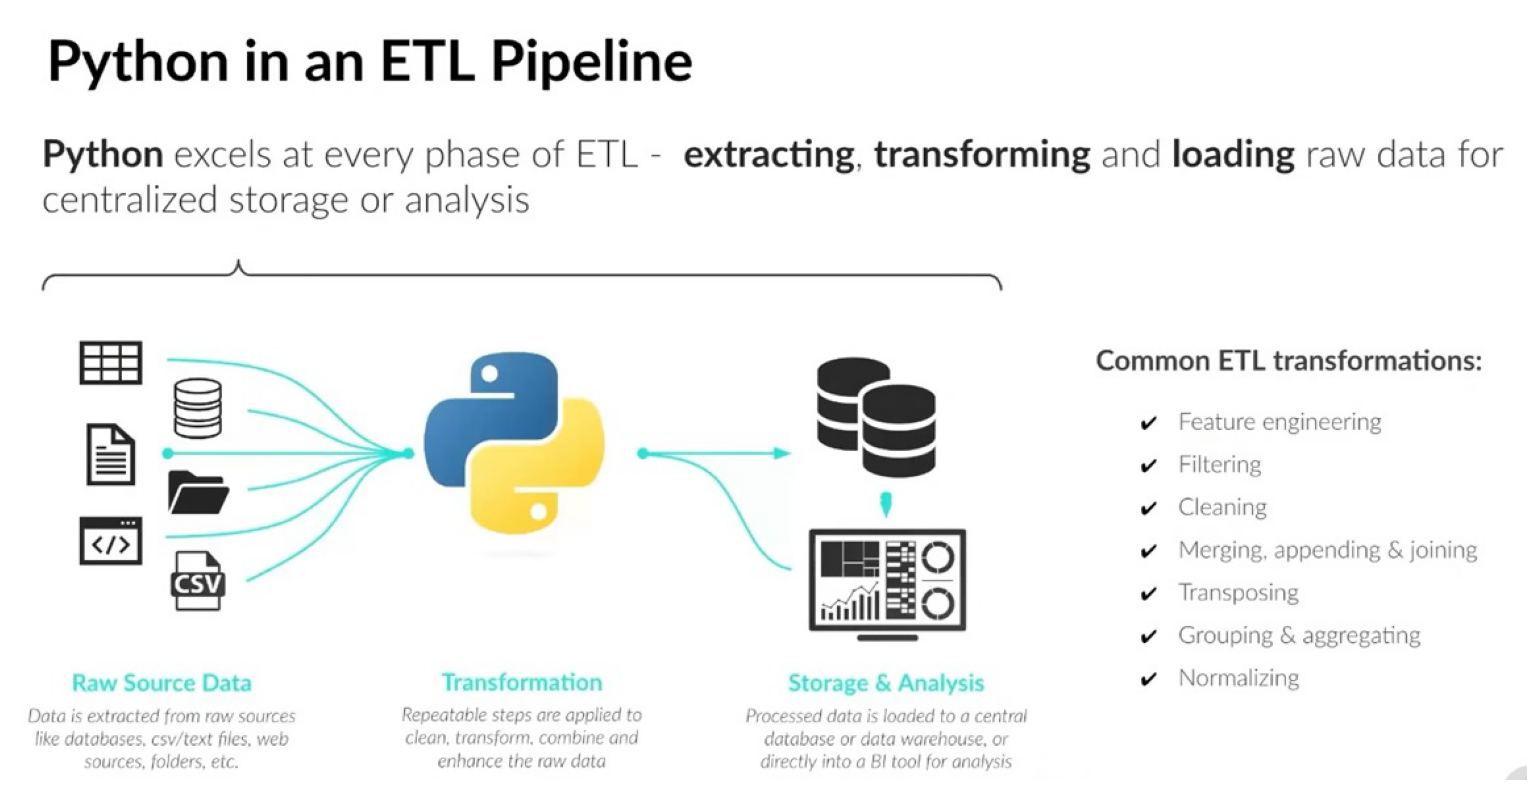

In [242]:
from PIL import Image                     # Import the Image class from the Python Imaging Library (PIL) to work with images
import matplotlib.pyplot as plt           # Import the pyplot module from matplotlib for creating and displaying plots

img = Image.open("Desktop\Developer Tools and Projects\Python\My Project\Test Project\ETL\ETL_Visual.jpg")    
# Open the image file at the given path and store it in the variable 'img'

plt.figure(figsize=(20, 10))              # Create a new figure with a size of 20 inches wide and 10 inches tall
plt.imshow(img)                           # Display the image stored in 'img' on the figure
plt.axis("off")                           # Hide the axis lines and labels for a cleaner look
plt.show()                                # Render and show the image in the output window


 Imports
 
     - Pandas for ETL
     - SQLite is a lightweight SQL database

In [47]:
import pandas as pd                      # Import pandas library for working with data tables
import sqlite3                           # Import sqlite3 library to connect and work with SQLite databases

conn = sqlite3.connect("Desktop/Developer Tools and Projects/Python/My Project/Test Project/ETL/sales.sqlite")  
# Create a connection to the SQLite database file 'sales.sqlite' and store it in the variable 'conn'

 Extract from Data Sources
     - Flat Files - read_csv(), read_json(), read_parquet
            # - Append Multiple Files
     - Databases - pd.read_sql() + sqlalchemy
     API - tap into web based resources

 Extract from Flat Files

In [48]:
sales_df = pd.read_csv("Desktop\Developer Tools and Projects\Python\My Project\Test Project\ETL\Retail_Sales.csv")  
# Read the CSV file 'Retail_Sales.csv' into a pandas DataFrame and store it in 'sales_df'

sales_df.head()  
# Display the first 5 rows of the DataFrame to quickly preview the data

,store_id,store_name,product_category,date,Unit sales,DOLLAR SALES,store_zip,promotion_flag
0,LA002,Store_2,Household,9/1/24,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,True
2,LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,True
3,LA003,Store_3,Household,9/7/24,7.0,25.69,90001,True
4,LA008,Store_8,Beverages,9/18/24,25.0,85.46,90005,False


In [40]:
sales_df.info()  
# Show a concise summary of the DataFrame 'sales_df', including:
    # - Number of rows and columns
    # - Column names and their data types
    # - Non‑null (filled) values for each column
    # - Memory usage of the DataFrame


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    object 
 1   store_name        750 non-null    object 
 2   product_category  750 non-null    object 
 3   date              750 non-null    object 
 4   Unit sales        745 non-null    float64
 5   DOLLAR SALES      743 non-null    float64
 6   store_zip         750 non-null    object 
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 41.9+ KB


In [246]:
import glob  
# Import the glob module to find files that match a specific pattern

file_paths = glob.glob("Desktop\Developer Tools and Projects\Python\My Project\Test Project\ETL\Sales_By_Day/*.csv")  
# Collect all CSV file paths inside the 'Sales_By_Day' folder and store them in the list 'file_paths'

sales_df = pd.concat([pd.read_csv(fp) for fp in file_paths], ignore_index=True)  
# Read each CSV file in 'file_paths' into a DataFrame, then combine them all into one DataFrame called 'sales_df'
# 'ignore_index=True' resets the row index so it runs continuously across all files

file_paths  
# Show the list of file paths that were found by glob

['Desktop\\Developer Tools and Projects\\Python\\My Project\\Test Project\\ETL\\Sales_By_Day\\sales_2024-09-01.csv',
 'Desktop\\Developer Tools and Projects\\Python\\My Project\\Test Project\\ETL\\Sales_By_Day\\sales_2024-09-02.csv',
 'Desktop\\Developer Tools and Projects\\Python\\My Project\\Test Project\\ETL\\Sales_By_Day\\sales_2024-09-03.csv',
 'Desktop\\Developer Tools and Projects\\Python\\My Project\\Test Project\\ETL\\Sales_By_Day\\sales_2024-09-04.csv',
 'Desktop\\Developer Tools and Projects\\Python\\My Project\\Test Project\\ETL\\Sales_By_Day\\sales_2024-09-05.csv',
 'Desktop\\Developer Tools and Projects\\Python\\My Project\\Test Project\\ETL\\Sales_By_Day\\sales_2024-09-06.csv',
 'Desktop\\Developer Tools and Projects\\Python\\My Project\\Test Project\\ETL\\Sales_By_Day\\sales_2024-09-07.csv',
 'Desktop\\Developer Tools and Projects\\Python\\My Project\\Test Project\\ETL\\Sales_By_Day\\sales_2024-09-08.csv',
 'Desktop\\Developer Tools and Projects\\Python\\My Project\\Tes

In [247]:
import os  
# Import the os module to work with file and directory paths

# Extract just the filenames from the full paths
short_paths = [os.path.basename(fp) for fp in file_paths]   # Get only the filename (e.g., 'sales_2024-09-01.csv') from each full path
short_paths  
# Display the list of filenames without the folder paths

['sales_2024-09-01.csv',
 'sales_2024-09-02.csv',
 'sales_2024-09-03.csv',
 'sales_2024-09-04.csv',
 'sales_2024-09-05.csv',
 'sales_2024-09-06.csv',
 'sales_2024-09-07.csv',
 'sales_2024-09-08.csv',
 'sales_2024-09-09.csv',
 'sales_2024-09-10.csv',
 'sales_2024-09-11.csv',
 'sales_2024-09-12.csv',
 'sales_2024-09-13.csv',
 'sales_2024-09-14.csv',
 'sales_2024-09-15.csv',
 'sales_2024-09-16.csv',
 'sales_2024-09-17.csv',
 'sales_2024-09-18.csv',
 'sales_2024-09-19.csv',
 'sales_2024-09-20.csv',
 'sales_2024-09-21.csv',
 'sales_2024-09-22.csv',
 'sales_2024-09-23.csv',
 'sales_2024-09-24.csv',
 'sales_2024-09-25.csv',
 'sales_2024-09-26.csv',
 'sales_2024-09-27.csv',
 'sales_2024-09-28.csv',
 'sales_2024-09-29.csv',
 'sales_2024-09-30.csv']

In [26]:
sales_df.head()

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True
2,LA008,Store_8,Produce,2024-09-01,4.0,79.99,90001,False
3,LA010,Store_10,Beverages,2024-09-01,22.0,140.45,90005,True
4,LA006,Store_6,Snacks,2024-09-01,17.0,50.03,90003,False


In [27]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    object 
 1   store_name        750 non-null    object 
 2   product_category  750 non-null    object 
 3   date              750 non-null    object 
 4   unit_sales        745 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         750 non-null    object 
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 41.9+ KB


In [68]:
sales_df = pd.DataFrame()

for day in range(1,6):
    day_df = pd.read_csv(fr"Desktop\Developer Tools and Projects\Python\My Project\Test Project\ETL\Sales_By_Day/sales_2024-09-{day:02d}.csv")
    sales_df = pd.concat([sales_df, day_df])

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 22
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          120 non-null    object 
 1   store_name        120 non-null    object 
 2   product_category  120 non-null    object 
 3   date              120 non-null    object 
 4   unit_sales        120 non-null    float64
 5   dollar_sales      120 non-null    float64
 6   store_zip         120 non-null    object 
 7   promotion_flag    120 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 7.6+ KB


In [248]:
sales_df = pd.read_json("Desktop/Developer Tools and Projects/Python/My Project/Test Project/ETL/Retail_Sales.json", lines=True)  
# Read the JSON file 'Retail_Sales.json' into a pandas DataFrame and store it in 'sales_df'
# The option 'lines=True' means the file is in JSON Lines format (one JSON object per line)

sales_df  
# Display the entire DataFrame to see all the loaded data

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True
2,LA004,Store_4,Produce,2024-09-15,18.0,298.26,90003,True
3,LA003,Store_3,Household,2024-09-07,7.0,25.69,90001,True
4,LA008,Store_8,Beverages,2024-09-18,25.0,85.46,90005,False
...,...,...,...,...,...,...,...,...
745,LA010,Store_10,Beverages,2024-09-24,46.0,790.99,90005,True
746,LA008,Store_8,Snacks,2024-09-14,23.0,375.40,90003,False
747,LA004,Store_4,Personal Care,2024-09-14,17.0,225.24,900XX,False
748,LA009,Store_9,Snacks,2024-09-28,37.0,406.47,90004,False


In [249]:
sales_df = pd.read_parquet("Desktop/Developer Tools and Projects/Python/My Project/Test Project/ETL/Retail_Sales.parquet")  
# Read the Parquet file 'Retail_Sales.parquet' into a pandas DataFrame and store it in 'sales_df'
# Parquet is a column‑based file format that is efficient for large datasets

sales_df  
# Display the entire DataFrame to see all the loaded data

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True
2,LA004,Store_4,Produce,2024-09-15,18.0,298.26,90003,True
3,LA003,Store_3,Household,2024-09-07,7.0,25.69,90001,True
4,LA008,Store_8,Beverages,2024-09-18,25.0,85.46,90005,False
...,...,...,...,...,...,...,...,...
745,LA010,Store_10,Beverages,2024-09-24,46.0,790.99,90005,True
746,LA008,Store_8,Snacks,2024-09-14,23.0,375.40,90003,False
747,LA004,Store_4,Personal Care,2024-09-14,17.0,225.24,900XX,False
748,LA009,Store_9,Snacks,2024-09-28,37.0,406.47,90004,False


Extract from SQL

In [175]:
sales_df = pd.read_sql("SELECT * FROM sales", con=conn)  
# Run the SQL query "SELECT * FROM sales" on the database connection 'conn'
# Load all rows and columns from the 'sales' table into a pandas DataFrame called 'sales_df'

sales_df  
# Display the DataFrame to see the data retrieved from the database

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit,temp
0,LA002,Store_2,Household,2024-09-01 00:00:00,16,96.28,90004,1,6.02,71.19
1,LA001,Store_1,Beverages,2024-09-01 00:00:00,14,86.63,90004,1,6.19,71.19
2,LA004,Store_4,Produce,2024-09-15 00:00:00,18,298.26,90003,1,16.57,63.91
3,LA003,Store_3,Household,2024-09-07 00:00:00,7,25.69,90001,1,3.67,78.37
4,LA008,Store_8,Beverages,2024-09-18 00:00:00,25,85.46,90005,0,3.42,60.82
...,...,...,...,...,...,...,...,...,...,...
733,LA010,Store_10,Beverages,2024-09-24 00:00:00,46,790.99,90005,1,17.20,66.04
734,LA008,Store_8,Snacks,2024-09-14 00:00:00,23,375.40,90003,0,16.32,64.98
735,LA004,Store_4,Personal Care,2024-09-14 00:00:00,17,225.24,90000,0,13.25,64.98
736,LA009,Store_9,Snacks,2024-09-28 00:00:00,37,406.47,90004,0,10.99,65.03


In [250]:
sales_df = pd.read_sql('''
    SELECT store_id, SUM(dollar_sales) AS total_sales
    FROM sales
    GROUP BY store_id
    ORDER BY total_sales DESC''', con=conn)  
# Run an SQL query on the database connection 'conn':
# - SELECT store_id and the total of 'dollar_sales' for each store
# - SUM(dollar_sales) calculates total sales per store
# - GROUP BY store_id groups rows by store
# - ORDER BY total_sales DESC sorts results from highest to lowest sales
# The results are loaded into a pandas DataFrame called 'sales_df'

sales_df  
# Display the DataFrame with store IDs and their total sales, sorted in descending order

,store_id,total_sales
0,LA010,26671.40
1,LA006,23636.70
2,LA009,22413.21
3,LA001,20941.15
4,LA008,20765.75
5,LA003,20731.63
6,LA002,20139.23
7,LA005,19757.50
8,LA004,16749.46
9,LA007,15860.04


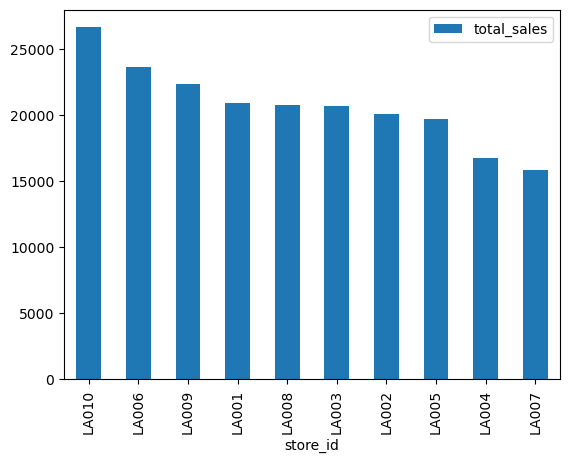

In [251]:
sales_df  = pd.read_sql('''
    SELECT store_id, SUM(dollar_sales) AS total_sales
    FROM sales
    GROUP BY store_id
    ORDER BY total_sales DESC''', con=conn).set_index("store_id").plot.bar()  
# Run an SQL query to:
# - SELECT store_id and total sales per store (SUM of dollar_sales)
# - GROUP BY store_id to calculate totals for each store
# - ORDER BY total_sales DESC to sort from highest to lowest
# Load results into a pandas DataFrame
# .set_index("store_id") sets 'store_id' as the index (x-axis labels)
# .plot.bar() creates a bar chart of total sales by store

Extract from API

In [112]:
import requests                          # Import requests library to make HTTP requests to web APIs
import time                              # Import time library (used later for delays between requests)
from datetime import datetime            # Import datetime class to work with dates and times

API_KEY = "5883b9ac08253fbd080c073b1832a6a8"  
# Your personal API key for accessing the OpenWeatherMap API

LAT, LON = 34.0522, -118.2437            # Latitude and longitude coordinates for Los Angeles

unix_timestamp = int(datetime.strptime(str(sales_df["date"][0].date()), "%Y-%m-%d").timestamp())  
# Convert the first date in 'sales_df' into a UNIX timestamp (seconds since Jan 1, 1970)

url = (
    f"https://api.openweathermap.org/data/3.0/onecall/timemachine"
    f"?lat={LAT}&lon={LON}&dt={unix_timestamp}&appid={API_KEY}&units=imperial"
)  
# Build the API request URL with location, date, API key, and units (imperial = Fahrenheit)

response = requests.get(url)  
# Send a GET request to the API and store the response in 'response'

In [113]:
sales_df["date"][0]  
# Access the first value in the 'date' column of the DataFrame 'sales_df'
# This returns a single date entry (the very first row's date)

Timestamp('2024-09-01 00:00:00')

In [115]:
int(datetime.strptime(str(sales_df["date"][0].date()), "%Y-%m-%d").timestamp())  
# Take the first date value from the 'date' column in 'sales_df'
# Convert it to a string in the format "YYYY-MM-DD"
# Use datetime.strptime() to turn that string into a datetime object
# .timestamp() converts the datetime into a UNIX timestamp (seconds since Jan 1, 1970)
# int() makes sure the timestamp is stored as an integer

1725120000

In [117]:
data = response.json()  
# Convert the API response into a Python dictionary using .json()
# This makes the weather data easy to work with in Python

data  
# Display the full JSON data returned by the API

{'lat': 34.0522,
 'lon': -118.2437,
 'timezone': 'America/Los_Angeles',
 'timezone_offset': -25200,
 'data': [{'dt': 1725120000,
   'sunrise': 1725110786,
   'sunset': 1725157213,
   'temp': 74.8,
   'feels_like': 75.97,
   'pressure': 1016,
   'humidity': 85,
   'dew_point': 70,
   'clouds': 50,
   'wind_speed': 3.65,
   'wind_deg': 196,
   'weather': [{'id': 802,
     'main': 'Clouds',
     'description': 'scattered clouds',
     'icon': '03d'}]}]}

In [121]:
data["data"][0]['temp']  
# Access the weather data dictionary 'data'
# Go into the "data" list and take the first element [0] (represents the first time entry)
# From that entry, get the value of 'temp' (temperature in Fahrenheit, since units=imperial)

74.8

In [124]:
dates = sales_df["date"].sort_values().dropna().unique()  
# Take the 'date' column from the DataFrame
# .sort_values() sorts all the dates in ascending order
# .dropna() removes any missing (NaN) values
# .unique() keeps only distinct dates (no duplicates)
# The result is an array of unique, sorted dates

dates  
# Display the array of cleaned, unique dates

<DatetimeArray>
['2024-09-01 00:00:00', '2024-09-02 00:00:00', '2024-09-03 00:00:00',
 '2024-09-04 00:00:00', '2024-09-05 00:00:00', '2024-09-06 00:00:00',
 '2024-09-07 00:00:00', '2024-09-08 00:00:00', '2024-09-09 00:00:00',
 '2024-09-10 00:00:00', '2024-09-11 00:00:00', '2024-09-12 00:00:00',
 '2024-09-13 00:00:00', '2024-09-14 00:00:00', '2024-09-15 00:00:00',
 '2024-09-16 00:00:00', '2024-09-17 00:00:00', '2024-09-18 00:00:00',
 '2024-09-19 00:00:00', '2024-09-20 00:00:00', '2024-09-21 00:00:00',
 '2024-09-22 00:00:00', '2024-09-23 00:00:00', '2024-09-24 00:00:00',
 '2024-09-25 00:00:00', '2024-09-26 00:00:00', '2024-09-27 00:00:00',
 '2024-09-28 00:00:00', '2024-09-29 00:00:00', '2024-09-30 00:00:00']
Length: 30, dtype: datetime64[ns]

In [127]:
weather_data = []  
# Create an empty list to store daily weather information

dates = sales_df.date.sort_values().dropna().unique()  
# Get all unique, sorted dates from the 'date' column (ignoring missing values)

for date in dates:  
    # Loop through each date in the dataset

    # Convert to UNIX timestamp (required for historical API)
    unix_timestamp = int(datetime.strptime(str(date.date()), "%Y-%m-%d").timestamp())

    url = (
        f"https://api.openweathermap.org/data/3.0/onecall/timemachine"
        f"?lat={LAT}&lon={LON}&dt={unix_timestamp}&appid={API_KEY}&units=imperial"
    )
    response = requests.get(url)  
    # Send request to OpenWeather API for historical weather data

    if response.status_code == 200:  
        # If the request was successful
        data = response.json()
        day_weather = {
            "date": date.date(),                          # Store the date
            "temp": data["data"][0]["temp"],              # Temperature (°F)
            "humidity": data["data"][0]["humidity"],      # Humidity (%)
            "weather_main": data["data"][0]["weather"][0]["main"],        # Main weather condition
            "weather_desc": data["data"][0]["weather"][0]["description"]  # Detailed description
        }
        weather_data.append(day_weather)  
        # Add this day's weather info to the list
    else:
        print(f"Failed to fetch data for {date.date()}: {response.status_code}")

    time.sleep(1)  
    # Pause for 1 second between requests to avoid hitting API limits

weather_df = pd.DataFrame(weather_data)  
# Convert the collected weather data into a pandas DataFrame

In [130]:
weather_df  
# Display the DataFrame 'weather_df' that contains the collected weather data
# Each row represents one date from your sales dataset
# Columns include:
#   - date: the sales date
#   - temp: temperature (°F)
#   - humidity: humidity (%)
#   - weather_main: main weather condition

,date,temp,humidity,weather_main,weather_desc
0,2024-09-01,74.80,85,Clouds,scattered clouds
1,2024-09-02,76.77,75,Clouds,scattered clouds
2,2024-09-03,78.10,81,Clouds,few clouds
3,2024-09-04,82.26,70,Clouds,scattered clouds
4,2024-09-05,82.13,78,Clouds,few clouds
5,2024-09-06,88.70,41,Clear,clear sky
6,2024-09-07,90.73,28,Clear,clear sky
7,2024-09-08,87.96,48,Clear,clear sky
8,2024-09-09,92.23,39,Clear,clear sky
9,2024-09-10,91.90,33,Clear,clear sky


In [132]:
weather_df.info()  
# Show a concise summary of the DataFrame 'weather_df', including:
# - Number of entries (rows) and columns
# - Column names and their data types
# - Non‑null counts for each column (to check missing values)
# - Memory usage of the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          30 non-null     object 
 1   temp          30 non-null     float64
 2   humidity      30 non-null     int64  
 3   weather_main  30 non-null     object 
 4   weather_desc  30 non-null     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.3+ KB


In [135]:
weather_df["date"] = pd.to_datetime(weather_df["date"])  
# Convert the 'date' column in 'weather_df' from plain date objects/strings into pandas datetime objects
# This ensures consistent handling of dates for plotting, filtering, and time‑based operations

weather_df.info()  
# Show a concise summary of the updated DataFrame
# Confirms that the 'date' column is now of type datetime64[ns]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          30 non-null     datetime64[ns]
 1   temp          30 non-null     float64       
 2   humidity      30 non-null     int64         
 3   weather_main  30 non-null     object        
 4   weather_desc  30 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 1.3+ KB


<Axes: xlabel='date'>

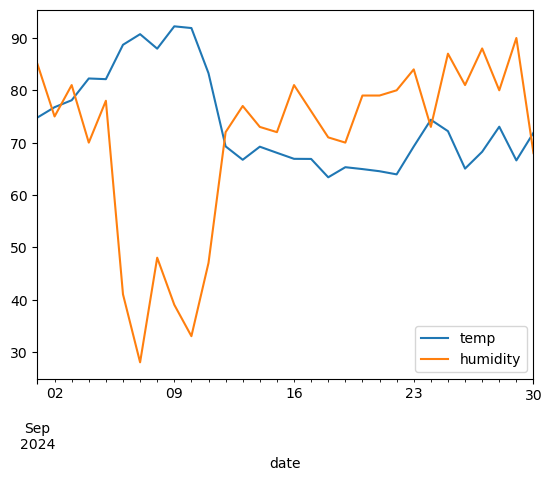

In [136]:
weather_df.set_index("date").plot.line()  
# Set the 'date' column as the index of the DataFrame (x-axis for the plot)
# .plot.line() creates a line chart of all numeric columns (temp, humidity, etc.)
# Each column will be drawn as a separate line across the timeline

TRANSFORM Pandas Data

In [198]:
sales_df = pd.read_csv("Desktop/Developer Tools and Projects/Python/My Project/Test Project/ETL/Retail_Sales.csv")  
# Read the CSV file 'Retail_Sales.csv' into a pandas DataFrame called 'sales_df'

# Apply snake casing and assign back
sales_df.columns = sales_df.columns.str.lower().str.replace(" ", "_")  
# Convert all column names to lowercase
# Replace spaces with underscores for cleaner, consistent column naming

sales_df.info()  
# Display a concise summary of the DataFrame:
# - Number of rows and columns
# - Column names and their data types
# - Non‑null counts (to check missing values)
# - Memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    object 
 1   store_name        750 non-null    object 
 2   product_category  750 non-null    object 
 3   date              750 non-null    object 
 4   unit_sales        745 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         750 non-null    object 
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 41.9+ KB


In [199]:
sales_df.query("unit_sales.isna()")  
# Use .query() to filter rows in 'sales_df'
# "unit_sales.isna()" keeps only rows where the 'unit_sales' column has missing values (NaN)
# Returns a DataFrame containing those rows

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
25,LA007,Store_7,Personal Care,9/16/24,NaN,245.89,90004,True
301,LA002,Store_2,Personal Care,9/21/24,NaN,8.47,90002,True
395,LA009,Store_9,household,9/7/24,NaN,18.06,90002,True
501,LA007,Store_7,Personal Care,9/28/24,NaN,60.13,90002,True
651,LA009,Store_9,Personal Care,9/23/24,NaN,305.32,90004,True


In [200]:
missing_unit_indices = sales_df.query("unit_sales.isna()").index  
# Find the row indices where 'unit_sales' is missing (NaN)

sales_df["unit_sales"] = sales_df["unit_sales"].fillna(0)  
# Replace all missing values in 'unit_sales' with 0

sales_df.iloc[missing_unit_indices]  
# Display the rows that originally had missing 'unit_sales'
# Now those rows will show 'unit_sales' filled with 0

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
25,LA007,Store_7,Personal Care,9/16/24,0.0,245.89,90004,True
301,LA002,Store_2,Personal Care,9/21/24,0.0,8.47,90002,True
395,LA009,Store_9,household,9/7/24,0.0,18.06,90002,True
501,LA007,Store_7,Personal Care,9/28/24,0.0,60.13,90002,True
651,LA009,Store_9,Personal Care,9/23/24,0.0,305.32,90004,True


In [216]:
sales_df = sales_df.dropna(subset=["dollar_sales"])  
# Drop all rows where 'dollar_sales' is missing (NaN)
# Keeps only rows with valid dollar_sales values

sales_df.info()  
# Show a concise summary of the cleaned DataFrame
# Confirms that 'dollar_sales' no longer has missing values

<class 'pandas.core.frame.DataFrame'>
Index: 743 entries, 0 to 749
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          743 non-null    object 
 1   store_name        743 non-null    object 
 2   product_category  743 non-null    object 
 3   date              743 non-null    object 
 4   unit_sales        743 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         743 non-null    object 
 7   promotion_flag    743 non-null    bool   
 8   rev_per_unit      743 non-null    float64
dtypes: bool(1), float64(3), object(5)
memory usage: 53.0+ KB


In [217]:
sales_df["rev_per_unit"] = sales_df["dollar_sales"] / sales_df["unit_sales"].round(2)  
# Create a new column 'rev_per_unit'
# Calculate revenue per unit by dividing 'dollar_sales' by 'unit_sales'
# .round(2) ensures unit_sales is rounded to 2 decimal places before division

sales_df.head()  
# Display the first 5 rows of the updated DataFrame
# Lets you quickly check that 'rev_per_unit' was added correctly

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit
0,LA002,Store_2,Household,9/1/24,16.0,96.28,90004,True,6.017500
1,LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,True,6.187857
2,LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,True,16.570000
3,LA003,Store_3,Household,9/7/24,7.0,25.69,90001,True,3.670000
4,LA008,Store_8,Beverages,9/18/24,25.0,85.46,90005,False,3.418400


In [219]:
sales_df["store_zip"] = sales_df["store_zip"].str.replace('XX', '00')  
# Replace any occurrence of 'XX' in the 'store_zip' column with '00'
# Ensures all ZIP codes are standardized and numeric‑friendly

sales_df.store_zip.value_counts()  
# Count how many times each ZIP code appears in the 'store_zip' column
# Returns a Series with ZIP codes as index and their frequency as values

store_zip
90003    137
90004    135
90001    124
90005    122
90000    118
90002    107
Name: count, dtype: int64

In [221]:
sales_df["date"] = pd.to_datetime(sales_df["date"], format='mixed')  
# Convert the 'date' column into pandas datetime objects
# 'mixed' format allows parsing of different date formats automatically

sales_df["promotion_flag"] = sales_df["promotion_flag"].astype(bool)  
# Convert the 'promotion_flag' column into boolean values (True/False)

sales_df["unit_sales"] = sales_df["unit_sales"].astype(int)  
# Convert the 'unit_sales' column into integers for consistency

In [223]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 743 entries, 0 to 749
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   store_id          743 non-null    object        
 1   store_name        743 non-null    object        
 2   product_category  743 non-null    object        
 3   date              743 non-null    datetime64[ns]
 4   unit_sales        743 non-null    int64         
 5   dollar_sales      743 non-null    float64       
 6   store_zip         743 non-null    object        
 7   promotion_flag    743 non-null    bool          
 8   rev_per_unit      743 non-null    float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 53.0+ KB


In [225]:
sales_df.describe()

,date,unit_sales,dollar_sales,rev_per_unit
count,743,743.000000,743.000000,743.000000
mean,2024-09-15 12:20:20.995962368,25.464334,279.496729,inf
min,2024-09-01 00:00:00,0.000000,5.330000,2.032340
25%,2024-09-08 12:00:00,13.000000,104.920000,6.575342
50%,2024-09-16 00:00:00,25.000000,224.690000,10.861905
75%,2024-09-23 00:00:00,38.000000,407.095000,15.401379
max,2024-09-30 00:00:00,50.000000,980.000000,inf
std,NaN,14.457709,217.190090,NaN


<Axes: ylabel='Frequency'>

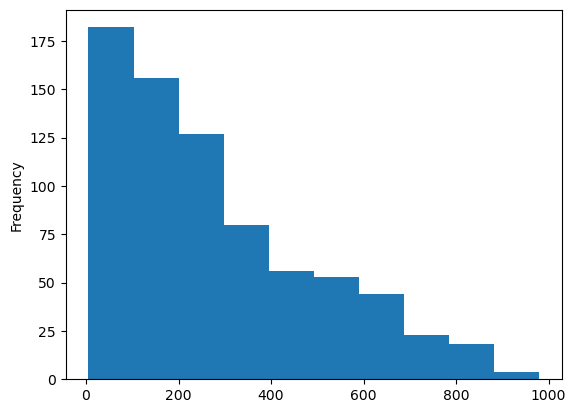

In [228]:
sales_df.dollar_sales.plot.hist()  
# Create a histogram of the 'dollar_sales' column
# Each bar shows how many transactions fall within a given sales range
# Useful for visualizing the distribution of sales amounts

<Axes: xlabel='dollar_sales', ylabel='Count'>

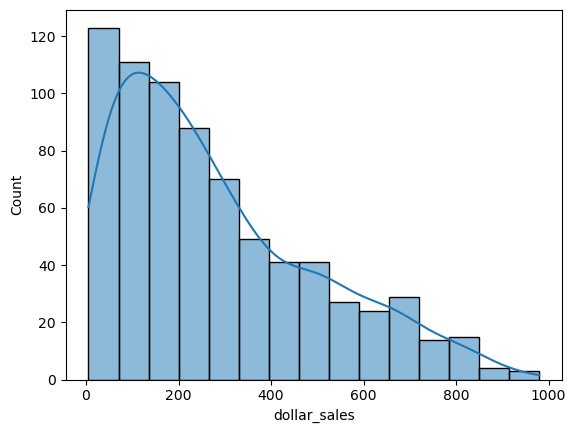

In [236]:
import seaborn as sns  

sns.histplot(data=sales_df, x="dollar_sales", kde=True)  
# Create a histogram of 'dollar_sales' using seaborn
# kde=True overlays a smooth Kernel Density Estimate curve
# This shows both the distribution of sales values (bars) and a smoothed trend line

MERGE API DATA

In [238]:
sales_df = sales_df.merge(weather_df[["date","temp"]], how="left", on="date")  
# Merge 'sales_df' with 'weather_df' on the 'date' column
# Keep all rows from sales_df (left join)
# Add the 'temp' column from weather_df to align daily sales with temperature

LOAD INTO SQL

In [239]:
sales_df.to_sql("Sales", if_exists="replace", index=False, con=conn)  
# Save the DataFrame 'sales_df' into the SQLite database connected via 'conn'
# Table name will be 'Sales'
# if_exists="replace" → drop the existing table (if any) and recreate it
# index=False → do not write the DataFrame index as a separate column

743

QUERY TOOL

In [241]:
pd.read_sql("SELECT * FROM Sales WHERE temp > 70", con=conn)  
# Run an SQL query on the SQLite connection 'conn'
# SELECT all columns from the 'Sales' table
# Only include rows where the 'temp' column (temperature) is greater than 70°F
# Load the results into a pandas DataFrame

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit,temp
0,LA002,Store_2,Household,2024-09-01 00:00:00,16,96.28,90004,1,6.017500,74.80
1,LA001,Store_1,Beverages,2024-09-01 00:00:00,14,86.63,90004,1,6.187857,74.80
2,LA003,Store_3,Household,2024-09-07 00:00:00,7,25.69,90001,1,3.670000,90.73
3,LA009,Store_9,Household,2024-09-08 00:00:00,50,798.40,90001,1,15.968000,87.96
4,LA004,Store_4,Produce,2024-09-30 00:00:00,46,352.55,90003,0,7.664130,71.89
...,...,...,...,...,...,...,...,...,...,...
360,LA002,Store_2,Snacks,2024-09-11 00:00:00,2,23.38,90004,1,11.690000,83.26
361,LA005,Store_5,Personal Care,2024-09-01 00:00:00,38,91.21,90004,0,2.400263,74.80
362,LA010,Store_10,Beverages,2024-09-24 00:00:00,46,790.99,90005,1,17.195435,74.37
363,LA009,Store_9,Snacks,2024-09-28 00:00:00,37,406.47,90004,0,10.985676,73.04
